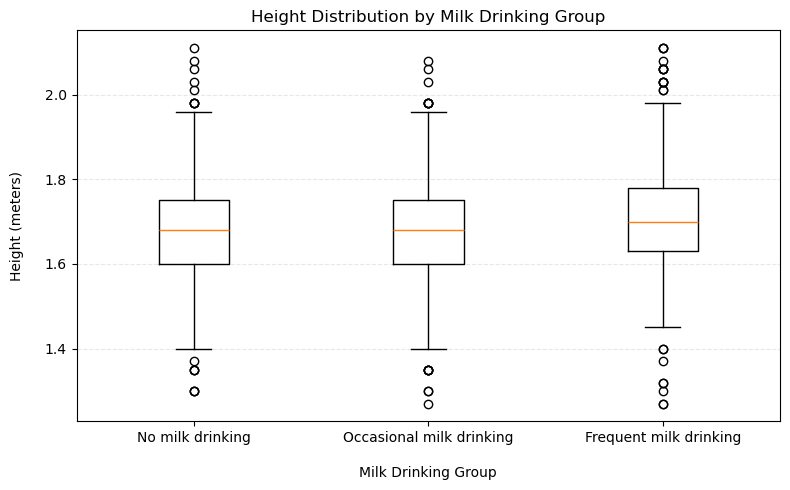

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 讀資料
# =========================
df = pd.read_csv("../data/processed/YRBS_Cleaned_and_Recoded.csv")

# =========================
# 2. 重新編碼（0/1/2 → 類別）
# =========================
label_map = {
    0: "No milk drinking",
    1: "Occasional milk drinking",
    2: "Frequent milk drinking"
}

df["NoMilkDrinking"] = df["NoMilkDrinking"].map(label_map)

# =========================
# 3. 定義 groups（一定要和 label 一致）
# =========================
groups = [
    "No milk drinking",
    "Occasional milk drinking",
    "Frequent milk drinking"
]

# =========================
# 4. 準備 boxplot 資料（去掉 NaN）
# =========================
data = [
    df[df["NoMilkDrinking"] == g]["HowTallAreYouWithoutShoesInMeters"].dropna()
    for g in groups
]

# =========================
# 5. 畫圖（新版 Matplotlib 寫法）
# =========================
plt.figure(figsize=(8, 5))

plt.boxplot(data, tick_labels=groups)  # ✔ 新版寫法（取代 labels）

plt.title("Height Distribution by Milk Drinking Group")
plt.xlabel("Milk Drinking Group", labelpad=15)
plt.ylabel("Height (meters)", labelpad=15)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Interpretation:
The boxplot compares height distributions across the no milk drinking, occasional milk drinking, and frequent milk drinking groups. A slight increasing trend in median height is observed from the no milk drinking group to the frequent milk drinking group. However, the distributions largely overlap, suggesting that the differences between groups may be small.

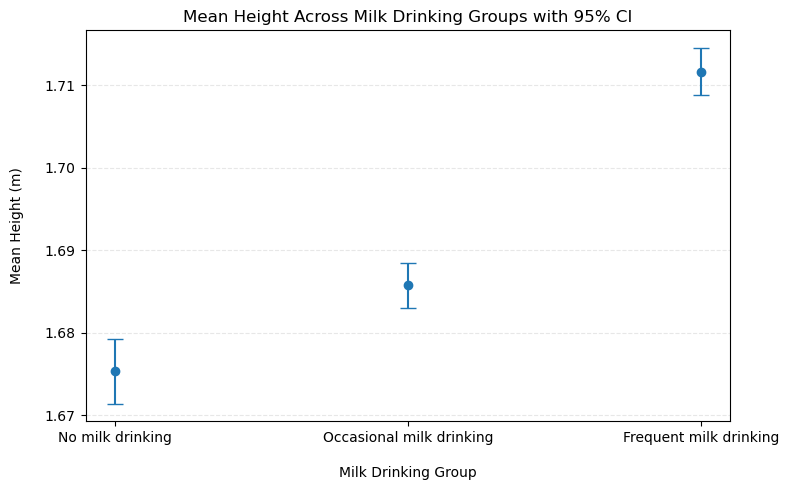

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. 讀資料
# =========================
df = pd.read_csv("../data/processed/YRBS_Cleaned_and_Recoded.csv")

# =========================
# 2. 重新編碼
# =========================
label_map = {
    0: "No milk drinking",
    1: "Occasional milk drinking",
    2: "Frequent milk drinking"
}

df["NoMilkDrinking"] = df["NoMilkDrinking"].map(label_map)

# =========================
# 3. 固定順序
# =========================
order = [
    "No milk drinking",
    "Occasional milk drinking",
    "Frequent milk drinking"
]

# =========================
# 4. 計算 mean / std / n
# =========================
summary = df.groupby("NoMilkDrinking")["HowTallAreYouWithoutShoesInMeters"].agg(
    mean="mean",
    std="std",
    count="count"
)

summary = summary.loc[order]

# =========================
# 5. 計算 95% CI
# =========================
summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci"] = 1.96 * summary["se"]

# =========================
# 6. 畫圖（CI版本）
# =========================
plt.figure(figsize=(8, 5))

plt.errorbar(
    summary.index,
    summary["mean"],
    yerr=summary["ci"],   # ✔ 改成 CI
    fmt='o',
    capsize=6
)

plt.title("Mean Height Across Milk Drinking Groups with 95% CI")
plt.xlabel("Milk Drinking Group", labelpad=15)
plt.ylabel("Mean Height (m)", labelpad=15)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Interpretation:
This figure shows the relationship between milk drinking frequency and height using mean values with 95% confidence intervals. A slight increasing trend in height is observed from the no milk drinking group to the frequent milk drinking group, and the limited overlap in confidence intervals suggests potential differences between groups.

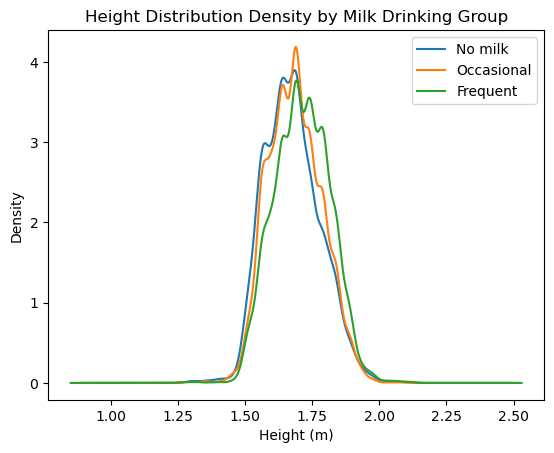

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/YRBS_Cleaned_and_Recoded.csv")

label_map = {
    0: "No milk",
    1: "Occasional",
    2: "Frequent"
}

df["NoMilkDrinking"] = df["NoMilkDrinking"].map(label_map)

plt.figure()

for group in ["No milk", "Occasional", "Frequent"]:
    df[df["NoMilkDrinking"] == group]["HowTallAreYouWithoutShoesInMeters"].plot(
        kind="density",
        label=group
    )

plt.title("Height Distribution Density by Milk Drinking Group")
plt.xlabel("Height (m)")
plt.legend()
plt.show()

Interpretation:
From the density plot, the Frequent milk drinking group shows a slight rightward shift in the distribution, suggesting a marginally higher height compared to the other groups. The No milk drinking group shows a slight leftward shift, indicating slightly lower heights, while the Occasional group lies between the two. However, the three distributions largely overlap, and differences in central tendency (mean/median) are small. This suggests that the effect size may be small, and group differences should be interpreted alongside the ANOVA results.